# S1-DS-04 — Pass-1 Data Audit

## Goal

Measure what is actually in the REES46 October 2019 data before any cohort rule or task
definition is fixed. Thresholds must come from observed distributions, not from guesses.

## What is waiting on these numbers

- **Cohort eligibility** — how many events, sessions and active days make a user usable
- **T3 protocol** — whether cart and purchase events are dense enough to define a target
- **Sessionisation policy** — what session gaps and durations actually look like

## This task measures. It does not decide.

No rule is chosen here: not the minimum event count, not the session timeout, not an outlier
policy. Every table below is phrased as *"if rule X were applied, Y would remain"* so the next
task can choose against evidence.

## Method

42,448,764 rows will not fit in memory. Everything comes from **one pass** over the 85 row
groups, accumulating counters as it goes. No number below is estimated from a sample.

In [1]:
"""S1-DS-04: measure activity distributions and data quality across the full dataset."""

import json
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import pyarrow.parquet as pq
import seaborn as sns

sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (11, 4)
pd.set_option("display.width", 220)
pd.set_option("display.max_columns", 40)

TASK_DIR = Path.cwd()
PROJECT_DIR = TASK_DIR.parent
SOURCE_PARQUET = PROJECT_DIR / "Dataset" / "processed_raw_parquet_v1.parquet"
OUTPUT_DIR = TASK_DIR / "output"
OUTPUT_DIR.mkdir(exist_ok=True)

parquet = pq.ParquetFile(SOURCE_PARQUET)
TOTAL_ROWS = parquet.metadata.num_rows
ROW_GROUPS = parquet.metadata.num_row_groups

print("Source     :", SOURCE_PARQUET.name)
print(f"Rows       : {TOTAL_ROWS:,}")
print(f"Row groups : {ROW_GROUPS}")

Source     : processed_raw_parquet_v1.parquet
Rows       : 42,448,764
Row groups : 85


## 1. Input reconciliation

Before analysing anything, prove we are analysing the approved data. The row count and the
event-type counts are checked against the manifest and the conversion report that `S1-DS-02`
produced. If either disagrees, the audit is measuring the wrong file.

In [2]:
def load_reference(name):
    """Read a reference JSON produced by S1-DS-02, if it is reachable."""
    for candidate in [PROJECT_DIR / "Repository" / "config" / name,
                      PROJECT_DIR / "Repository" / "docs" / "evidence" / "s1-ds-02" / name,
                      PROJECT_DIR / "Dataset" / name]:
        if candidate.is_file():
            return json.loads(candidate.read_text(encoding="utf-8")), candidate
    return None, None


manifest, manifest_path = load_reference("dataset_manifest.v1.json")
report, report_path = load_reference("conversion_report.v1.json")

print("DatasetManifest  :", manifest_path if manifest else "not found")
print("ConversionReport :", report_path if report else "not found")

expected_rows = None
expected_types = None
if report:
    expected_rows = report.get("accepted_rows")
    expected_types = report.get("event_counts")
elif manifest:
    expected_rows = manifest.get("raw_file", {}).get("row_count")

print()
print("Expected accepted rows :", f"{expected_rows:,}" if expected_rows else "unknown")
print("Expected event counts  :", expected_types or "unknown")

DatasetManifest  : E:\Graduation Project Microsoft\Repository\config\dataset_manifest.v1.json
ConversionReport : E:\Graduation Project Microsoft\Repository\docs\evidence\s1-ds-02\conversion_report.v1.json

Expected accepted rows : 42,448,764
Expected event counts  : {'cart': 926516, 'purchase': 742849, 'view': 40779399}


In [3]:
schema = parquet.schema_arrow
print("Input schema:")
for field in schema:
    print(f"  {field.name:20} {field.type}")

Input schema:
  event_time           timestamp[us, tz=UTC]
  event_type           large_string
  product_id           large_string
  category_id          large_string
  category_code        large_string
  brand                large_string
  price                double
  user_id              large_string
  user_session         large_string
  source               large_string
  source_file          large_string
  source_row_number    int64


## 2. The single pass

Each row group is read once and every counter is updated from it, then the chunk is released.

Three choices keep this fast and inside memory:

- **Numeric ids become integers.** `user_id`, `product_id`, `category_id` and
  `source_row_number` are numeric strings. As `int64` they cost a fraction of the string form.
- **Sessions are hashed.** A session is identified by the pair `(user_id, user_session)`,
  hashed into one 64-bit key. We only ever count sessions, never read an id back.
- **`combine_first`, not `combine`.** The file is ordered by `event_time`, so a user's first
  event is whichever value is already held and their last event is whichever chunk is newer.
  `combine_first` is vectorised; the elementwise `combine` was measured ~11x slower here.

The ordering assumption is asserted rather than trusted.

In [4]:
COLUMNS = ["event_time", "event_type", "product_id", "category_id", "category_code",
           "brand", "price", "user_id", "user_session", "source_file", "source_row_number"]

# --- per-user accumulators
events_per_user = pd.Series(dtype="int64")
carts_per_user = pd.Series(dtype="int64")
purchases_per_user = pd.Series(dtype="int64")
first_seen = pd.Series(dtype="datetime64[us, UTC]")
last_seen = pd.Series(dtype="datetime64[us, UTC]")

# --- global counters
event_type_counts = pd.Series(dtype="int64")
null_counts = pd.Series(0, index=COLUMNS, dtype="int64")

# --- collected per chunk, combined once at the end
session_parts = []       # per-session count / first / last / cart / purchase
user_session_parts = []  # unique (user, session) pairs, for sessions-per-user
daily_parts = []         # per-day events by type
daily_user_parts = []    # unique (day, user) pairs
daily_session_parts = [] # unique (day, session) pairs
price_values = []
provenance_values = []   # source_row_number, to detect a re-ingested raw row
event_fingerprints = []  # same user+time+item+type, to detect a repeated event

items, categories, category_codes, brands = set(), set(), set(), set()

rows_seen = 0
previous_time = None
time_sorted = True
order_violations = 0

for group in range(ROW_GROUPS):
    chunk = parquet.read_row_group(group, columns=COLUMNS).to_pandas()
    rows_seen += len(chunk)
    null_counts += chunk.isna().sum()

    user = chunk["user_id"].astype("int64")
    times = chunk["event_time"]
    is_cart = chunk["event_type"] == "cart"
    is_purchase = chunk["event_type"] == "purchase"

    # ordering: within the chunk, and across the chunk boundary
    order_violations += int((times.diff().dt.total_seconds() < 0).sum())
    if previous_time is not None and times.iloc[0] < previous_time:
        time_sorted = False
    previous_time = times.iloc[-1]

    # per-user
    events_per_user = events_per_user.add(user.value_counts(), fill_value=0)
    carts_per_user = carts_per_user.add(user[is_cart].value_counts(), fill_value=0)
    purchases_per_user = purchases_per_user.add(user[is_purchase].value_counts(), fill_value=0)

    chunk_first = times.groupby(user).min()
    chunk_last = times.groupby(user).max()
    first_seen = first_seen.combine_first(chunk_first) if len(first_seen) else chunk_first
    last_seen = chunk_last.combine_first(last_seen) if len(last_seen) else chunk_last

    # per-session, keyed by the (user, session) pair
    session_key = pd.util.hash_pandas_object(
        pd.DataFrame({"u": chunk["user_id"], "s": chunk["user_session"]}), index=False)
    grouped = times.groupby(session_key)
    session_parts.append(pd.DataFrame({
        "events": grouped.count(),
        "first": grouped.min(),
        "last": grouped.max(),
        "carts": is_cart.groupby(session_key).sum(),
        "purchases": is_purchase.groupby(session_key).sum(),
        "null_session": chunk["user_session"].isna().groupby(session_key).max(),
    }))

    user_session_parts.append(
        pd.DataFrame({"user": user, "session": session_key}).drop_duplicates())

    # per-day
    day = times.dt.date
    daily_parts.append(pd.crosstab(day, chunk["event_type"]))
    daily_user_parts.append(pd.DataFrame({"day": day, "user": user}).drop_duplicates())
    daily_session_parts.append(
        pd.DataFrame({"day": day, "session": session_key}).drop_duplicates())

    # quality
    event_type_counts = event_type_counts.add(chunk["event_type"].value_counts(), fill_value=0)
    price_values.append(chunk["price"].to_numpy(dtype="float64"))
    provenance_values.append(chunk["source_row_number"].to_numpy(dtype="int64"))
    event_fingerprints.append(pd.util.hash_pandas_object(
        chunk[["user_id", "event_time", "product_id", "event_type"]], index=False).to_numpy())

    items.update(chunk["product_id"].astype("int64").unique())
    categories.update(chunk["category_id"].astype("int64").unique())
    category_codes.update(chunk["category_code"].dropna().unique())
    brands.update(chunk["brand"].dropna().unique())

    if (group + 1) % 20 == 0:
        print(f"  {group + 1}/{ROW_GROUPS} row groups")

print()
print(f"Rows read : {rows_seen:,}")

  20/85 row groups


  40/85 row groups


  60/85 row groups


  80/85 row groups



Rows read : 42,448,764


In [5]:
# Combine everything collected per chunk into its final form.
events_per_user = events_per_user.astype("int64")
carts_per_user = carts_per_user.reindex(events_per_user.index, fill_value=0).astype("int64")
purchases_per_user = purchases_per_user.reindex(events_per_user.index, fill_value=0).astype("int64")
span_days = (last_seen - first_seen).dt.total_seconds() / 86400

# Calendar dates touched between the first and last event. Active days can never
# exceed this, while the raw span in days can be smaller: a user seen at 23:00 and
# again at 01:00 the next day spans 2 hours but touches 2 dates.
dates_covered = (last_seen.dt.normalize() - first_seen.dt.normalize()).dt.days + 1

sessions = pd.concat(session_parts).groupby(level=0).agg(
    events=("events", "sum"),
    first=("first", "min"),
    last=("last", "max"),
    carts=("carts", "sum"),
    purchases=("purchases", "sum"),
    null_session=("null_session", "max"),
)
session_duration = (sessions["last"] - sessions["first"]).dt.total_seconds()

unique_day_user = pd.concat(daily_user_parts).drop_duplicates()

# True active days: distinct calendar dates on which a user produced at least one
# event. This is NOT the same as last_seen - first_seen: a user active on 1 and 31
# October spans 30 days but is active on only 2 of them.
active_days_per_user = (unique_day_user.groupby("user").size()
                        .reindex(events_per_user.index, fill_value=0))

daily = pd.concat(daily_parts).groupby(level=0).sum().sort_index()
daily["events"] = daily.sum(axis=1)
daily["users"] = unique_day_user.groupby("day").size()
daily["sessions"] = pd.concat(daily_session_parts).drop_duplicates().groupby("day").size()

prices = pd.Series(np.concatenate(price_values))
provenance = pd.Series(np.concatenate(provenance_values))
fingerprints = pd.Series(np.concatenate(event_fingerprints))

user_session_counts = (pd.concat(user_session_parts).drop_duplicates()
                       .groupby("user").size())
sessions_per_user = user_session_counts.reindex(events_per_user.index, fill_value=0)

del session_parts, user_session_parts, daily_parts, daily_user_parts, daily_session_parts
del unique_day_user
del price_values, provenance_values, event_fingerprints

print(f"Users    : {len(events_per_user):,}")
print(f"Sessions : {len(sessions):,}")
print(f"Days     : {len(daily)}")
assert int(sessions_per_user.sum()) == len(sessions), "session counts do not reconcile"
assert bool((active_days_per_user
             <= dates_covered.reindex(active_days_per_user.index)).all()),     "active days cannot exceed the calendar dates between first and last event"

Users    : 3,022,290
Sessions : 9,244,772
Days     : 31


### Reconciliation against the approved source

Three independent checks that the pass covered the right data, in full.

In [6]:
checks = []


def check(name, actual, expected, note=""):
    ok = expected is None or actual == expected
    checks.append({"check": name, "actual": actual, "expected": expected,
                   "status": "PASS" if ok else ("SKIP" if expected is None else "FAIL"),
                   "note": note})
    return ok


check("rows read == parquet header", rows_seen, TOTAL_ROWS)
check("rows read == conversion report", rows_seen, expected_rows,
      "S1-DS-02 accepted_rows" if expected_rows else "reference not found")
check("event-type counts sum to total", int(event_type_counts.sum()), TOTAL_ROWS)

if expected_types:
    for name, expected_count in sorted(expected_types.items()):
        check(f"{name} count matches S1-DS-02",
              int(event_type_counts.get(name, 0)), int(expected_count))

reconciliation = pd.DataFrame(checks)
print(reconciliation.to_string(index=False))

assert time_sorted, "file is not ordered by event_time; the first/last logic assumes it is"
assert rows_seen == TOTAL_ROWS, "the pass did not cover every row"

                          check   actual  expected status                   note
    rows read == parquet header 42448764  42448764   PASS                       
 rows read == conversion report 42448764  42448764   PASS S1-DS-02 accepted_rows
 event-type counts sum to total 42448764  42448764   PASS                       
    cart count matches S1-DS-02   926516    926516   PASS                       
purchase count matches S1-DS-02   742849    742849   PASS                       
    view count matches S1-DS-02 40779399  40779399   PASS                       


## 3. Core dataset volumes

Unique counts exclude missing values: a row with no `brand` does not add a brand. The
difference between `category_id` and `category_code` is the point of interest — one is always
present, the other is not.

In [7]:
volume = pd.DataFrame([
    ("Total events",           TOTAL_ROWS),
    ("Unique users",           len(events_per_user)),
    ("Unique sessions",        len(sessions)),
    ("Unique items",           len(items)),
    ("Unique category_id",     len(categories)),
    ("Unique category_code",   len(category_codes)),
    ("Unique brands",          len(brands)),
    ("Active days",            len(daily)),
], columns=["measure", "count"])

print(volume.to_string(index=False))
print()
print("Unique counts ignore missing values (a null brand adds no brand).")

             measure    count
        Total events 42448764
        Unique users  3022290
     Unique sessions  9244772
        Unique items   166794
  Unique category_id      624
Unique category_code      126
       Unique brands     3445
         Active days       31

Unique counts ignore missing values (a null brand adds no brand).


## 4. Event types and sparsity

Rarity at the event level is not the same as rarity at the user or session level. All three
are reported, because T2 and T3 depend on how many *decision points* exist, not on raw volume.

In [8]:
event_type_counts = event_type_counts.astype("int64").sort_values(ascending=False)

types = pd.DataFrame({
    "events": event_type_counts,
    "percent": (event_type_counts / TOTAL_ROWS * 100).round(2),
})
print(types.to_string())
print()

total_users = len(events_per_user)
total_sessions = len(sessions)
users_with_cart = int((carts_per_user > 0).sum())
users_with_purchase = int((purchases_per_user > 0).sum())
sessions_with_cart = int((sessions["carts"] > 0).sum())
sessions_with_purchase = int((sessions["purchases"] > 0).sum())

sparsity = pd.DataFrame([
    ("users with >= 1 cart",       users_with_cart,       users_with_cart / total_users * 100),
    ("users with >= 1 purchase",   users_with_purchase,   users_with_purchase / total_users * 100),
    ("sessions with >= 1 cart",    sessions_with_cart,    sessions_with_cart / total_sessions * 100),
    ("sessions with >= 1 purchase", sessions_with_purchase, sessions_with_purchase / total_sessions * 100),
], columns=["measure", "count", "percent"])
sparsity["percent"] = sparsity["percent"].round(2)

print(sparsity.to_string(index=False))

              events  percent
event_type                   
view        40779399    96.07
cart          926516     2.18
purchase      742849     1.75



                    measure  count  percent
       users with >= 1 cart 337117    11.15
   users with >= 1 purchase 347118    11.49
    sessions with >= 1 cart 573099     6.20
sessions with >= 1 purchase 629560     6.81


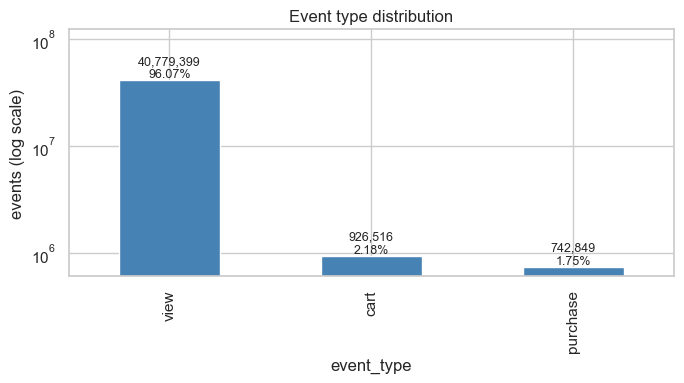

In [9]:
figure, axis = plt.subplots(figsize=(7, 4))

# Views outnumber the rest ~50 to 1, so the axis is logarithmic and the exact
# counts are printed on the bars - otherwise cart and purchase are invisible.
event_type_counts.plot(kind="bar", ax=axis, color="steelblue", title="Event type distribution")
axis.set_yscale("log")
axis.set_ylabel("events (log scale)")
for position, value in enumerate(event_type_counts):
    axis.text(position, value, f"{value:,}\n{value / TOTAL_ROWS * 100:.2f}%",
              ha="center", va="bottom", fontsize=9)
axis.set_ylim(top=event_type_counts.max() * 3)

plt.tight_layout()
plt.show()

## 5. Events per user

The percentiles matter more than the mean here, and the counts below them are **feasibility
numbers, not cohort thresholds**. They answer "if a rule required N events, how many users
would remain", nothing more.

### Two different ways to measure reach in time

- **Active days** — the count of distinct calendar dates on which a user produced at least
  one event.
- **Calendar span** — `last_seen - first_seen`, the distance between the first and last event.

They are not interchangeable. A user seen on 1 October and again on 31 October has a span of
30 days but is active on only 2 of them. Using span as an eligibility signal would admit users
with almost no repeated activity, so the feasibility grid below uses **active days**, and span
is kept only as a descriptive measure.

In [10]:
def percentiles(series, name):
    """The percentiles that actually inform a threshold decision."""
    return pd.Series({
        "count": len(series),
        "mean": round(series.mean(), 2),
        "p50": series.quantile(0.50),
        "p90": series.quantile(0.90),
        "p95": series.quantile(0.95),
        "p99": series.quantile(0.99),
        "max": series.max(),
    }, name=name)


print(percentiles(events_per_user, "events per user").to_string())
print()

# Two different things, reported separately on purpose.
reach_in_time = pd.concat([
    percentiles(active_days_per_user, "active days (distinct dates)"),
    percentiles(span_days.reindex(events_per_user.index, fill_value=0),
                "calendar span (last - first)"),
], axis=1)
print(reach_in_time.round(2).to_string())
print()
print("A user active on 1 and 31 October spans 30 days but is active on 2 of them.")
print("Cohort feasibility below uses active days, the stricter of the two.")
print()

day_reach = pd.DataFrame([{
    "min_active_days": threshold,
    "users": int((active_days_per_user >= threshold).sum()),
    "user_percent": round((active_days_per_user >= threshold).mean() * 100, 2),
} for threshold in [1, 2, 3, 7, 14]])
print(day_reach.to_string(index=False))
print()

thresholds = [1, 2, 5, 10, 20, 50, 100]
user_reach = pd.DataFrame([{
    "min_events": threshold,
    "users": int((events_per_user >= threshold).sum()),
    "user_percent": round((events_per_user >= threshold).mean() * 100, 2),
    "events_held": int(events_per_user[events_per_user >= threshold].sum()),
    "event_percent": round(events_per_user[events_per_user >= threshold].sum() / TOTAL_ROWS * 100, 2),
} for threshold in thresholds])

print(user_reach.to_string(index=False))
print()
print("Feasibility counts only. S1-DS-05 chooses the rule.")

count    3022290.00
mean          14.05
p50            4.00
p90           34.00
p95           57.00
p99          141.00
max         7436.00



       active days (distinct dates)  calendar span (last - first)
count                    3022290.00                    3022290.00
mean                           2.14                          5.28
p50                            1.00                          0.01
p90                            4.00                         19.84
p95                            6.00                         24.17
p99                           11.00                         28.84
max                           31.00                         30.93

A user active on 1 and 31 October spans 30 days but is active on 2 of them.
Cohort feasibility below uses active days, the stricter of the two.

 min_active_days   users  user_percent
               1 3022290        100.00
               2 1279795         42.35
               3  715944         23.69
               7  138478          4.58
              14   16928          0.56



 min_events   users  user_percent  events_held  event_percent
          1 3022290        100.00     42448764         100.00
          2 2331044         77.13     41757518          98.37
          5 1503009         49.73     39442728          92.92
         10  971704         32.15     35908139          84.59
         20  544006         18.00     30045857          70.78
         50  183340          6.07     19029051          44.83
        100   59146          1.96     10569041          24.90

Feasibility counts only. S1-DS-05 chooses the rule.


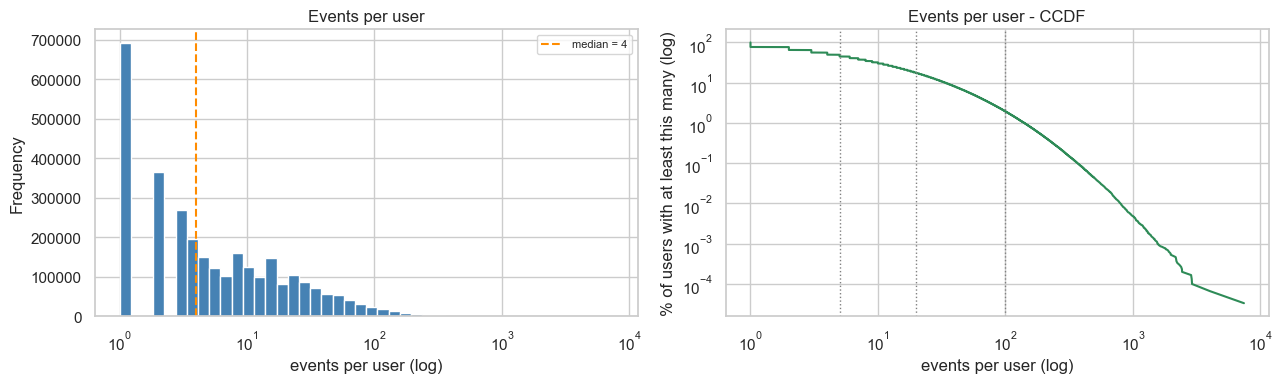

In [11]:
figure, axes = plt.subplots(1, 2, figsize=(13, 4))

# Log bins and a log axis. Nothing is clipped: piling the heavy users into an edge
# bin would invent a spike at the cut-off that is not in the data.
bins = np.logspace(0, np.log10(events_per_user.max()), 45)
events_per_user.plot(kind="hist", bins=bins, ax=axes[0], color="steelblue",
                     title="Events per user")
axes[0].set_xscale("log")
axes[0].set_xlabel("events per user (log)")
axes[0].axvline(events_per_user.median(), color="darkorange", linestyle="--",
                label=f"median = {events_per_user.median():.0f}")
axes[0].legend(fontsize=8)

# CCDF: the share of users with at least N events. The tail stays visible.
ordered = np.sort(events_per_user.to_numpy())
survival = 1.0 - np.arange(len(ordered)) / len(ordered)
axes[1].plot(ordered, survival * 100, color="seagreen")
axes[1].set_xscale("log")
axes[1].set_yscale("log")
axes[1].set_xlabel("events per user (log)")
axes[1].set_ylabel("% of users with at least this many (log)")
axes[1].set_title("Events per user - CCDF")
for threshold in [5, 20, 100]:
    axes[1].axvline(threshold, color="grey", linestyle=":", linewidth=1)

plt.tight_layout()
plt.show()

## 6. Sessions per user

Whether users come back at all decides if there is any repeated-visit signal to learn from.

In [12]:
# sessions_per_user was reconciled against the session table during the pass.
print(percentiles(sessions_per_user, "sessions per user").to_string())
print()

session_reach = pd.DataFrame([{
    "min_sessions": threshold,
    "users": int((sessions_per_user >= threshold).sum()),
    "user_percent": round((sessions_per_user >= threshold).mean() * 100, 2),
} for threshold in [1, 2, 3, 5, 10]])

print(session_reach.to_string(index=False))
print()

# Measured explicitly rather than inferred from the reach table, because these two
# groups carry no sequence at all and every later task has to account for them.
single_event_users = int((events_per_user == 1).sum())
single_session_users = int((sessions_per_user == 1).sum())

print(f"Users with exactly one event   : {single_event_users:,} "
      f"({single_event_users / len(events_per_user) * 100:.1f}%)")
print(f"Users with exactly one session : {single_session_users:,} "
      f"({single_session_users / len(events_per_user) * 100:.1f}%)")

count    3022290.00
mean           3.06
p50            2.00
p90            7.00
p95           10.00
p99           21.00
max         7400.00

 min_sessions   users  user_percent
            1 3022290        100.00
            2 1546827         51.18
            3  981310         32.47
            5  507985         16.81
           10  166751          5.52

Users with exactly one event   : 691,246 (22.9%)
Users with exactly one session : 1,475,463 (48.8%)


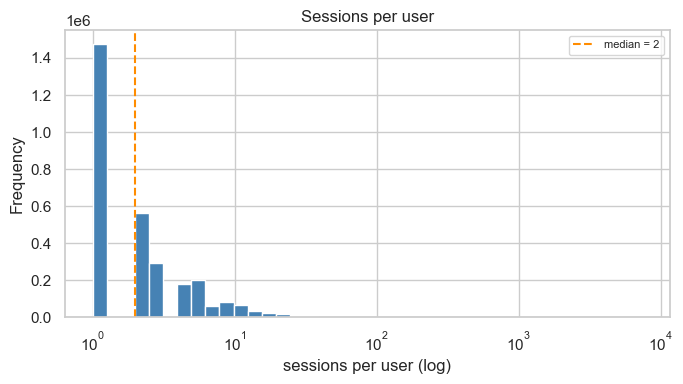

In [13]:
figure, axis = plt.subplots(figsize=(7, 4))

bins = np.logspace(0, np.log10(sessions_per_user.max()), 40)
sessions_per_user[sessions_per_user > 0].plot(
    kind="hist", bins=bins, ax=axis, color="steelblue", title="Sessions per user")
axis.set_xscale("log")
axis.set_xlabel("sessions per user (log)")
axis.axvline(sessions_per_user.median(), color="darkorange", linestyle="--",
             label=f"median = {sessions_per_user.median():.0f}")
axis.legend(fontsize=8)

plt.tight_layout()
plt.show()

## 7. Events per session

A session with one event carries no within-session sequence at all, so the share of those is
as important as the average.

In [14]:
events_per_session = sessions["events"]

print(percentiles(events_per_session, "events per session").to_string())
print()

single_event_sessions = int((events_per_session == 1).sum())
print(f"Single-event sessions : {single_event_sessions:,} "
      f"({single_event_sessions / len(sessions) * 100:.1f}%)")
print(f"Sessions with >= 5    : {int((events_per_session >= 5).sum()):,}")
print(f"Sessions with >= 10   : {int((events_per_session >= 10).sum()):,}")

count    9244772.00
mean           4.59
p50            2.00
p90           10.00
p95           16.00
p99           32.00
max         1159.00

Single-event sessions : 3,270,069 (35.4%)
Sessions with >= 5    : 2,678,394
Sessions with >= 10   : 1,075,408


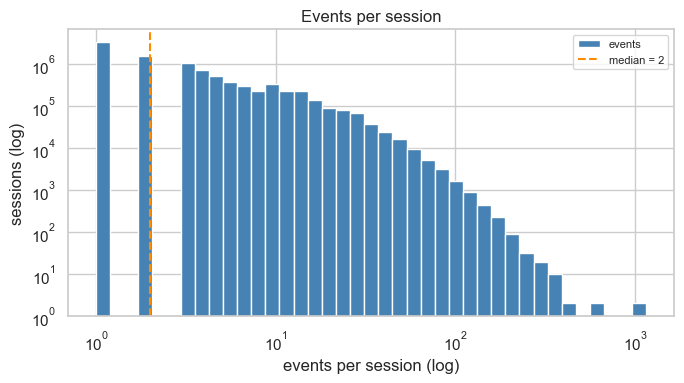

In [15]:
figure, axis = plt.subplots(figsize=(7, 4))

bins = np.logspace(0, np.log10(events_per_session.max()), 40)
events_per_session.plot(kind="hist", bins=bins, ax=axis, color="steelblue",
                        title="Events per session")
axis.set_xscale("log")
axis.set_yscale("log")
axis.set_xlabel("events per session (log)")
axis.set_ylabel("sessions (log)")
axis.axvline(events_per_session.median(), color="darkorange", linestyle="--",
             label=f"median = {events_per_session.median():.0f}")
axis.legend(fontsize=8)

plt.tight_layout()
plt.show()

## 8. Session duration

Observations only. The numbers below describe how long the **provided** sessions run; they do
not set a timeout. Any inactivity rule is a decision for the sessionisation task, and the
counts here exist so that decision can be argued from data.

In [16]:
print(percentiles(session_duration, "session duration (seconds)").round(1).to_string())
print()

duration_buckets = pd.DataFrame([
    ("zero duration (single instant)", int((session_duration == 0).sum())),
    ("under 1 minute",                 int((session_duration < 60).sum())),
    ("over 30 minutes",                int((session_duration > 1800).sum())),
    ("over 1 hour",                    int((session_duration > 3600).sum())),
    ("over 6 hours",                   int((session_duration > 21600).sum())),
    ("over 24 hours",                  int((session_duration > 86400).sum())),
], columns=["bucket", "sessions"])
duration_buckets["percent"] = (duration_buckets["sessions"] / len(sessions) * 100).round(2)

print(duration_buckets.to_string(index=False))
print()
print("Descriptive only - no session timeout is decided in this task.")

count    9244772.0
mean        1041.8
p50           63.0
p90          716.0
p95         1265.0
p99         4713.0
max      2640529.0

                        bucket  sessions  percent
zero duration (single instant)   3271644    35.39
                under 1 minute   4546154    49.18
               over 30 minutes    295153     3.19
                   over 1 hour    127358     1.38
                  over 6 hours     31307     0.34
                 over 24 hours     17086     0.18

Descriptive only - no session timeout is decided in this task.


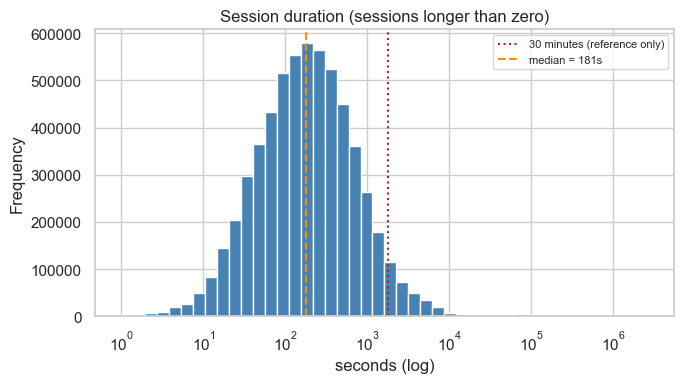

In [17]:
figure, axis = plt.subplots(figsize=(7, 4))

positive_duration = session_duration[session_duration > 0]
bins = np.logspace(0, np.log10(positive_duration.max()), 45)
positive_duration.plot(kind="hist", bins=bins, ax=axis, color="steelblue",
                       title="Session duration (sessions longer than zero)")
axis.set_xscale("log")
axis.set_xlabel("seconds (log)")
axis.axvline(1800, color="firebrick", linestyle=":", label="30 minutes (reference only)")
axis.axvline(positive_duration.median(), color="darkorange", linestyle="--",
             label=f"median = {positive_duration.median():.0f}s")
axis.legend(fontsize=8)

plt.tight_layout()
plt.show()

## 9. Time coverage and daily activity

Gaps, drops and spikes in a daily timeline are how ingestion problems surface. A temporal
split built on a month with a hole in it would be quietly wrong.

In [18]:
expected_days = pd.date_range(daily.index.min(), daily.index.max(), freq="D").date
missing_days = sorted(set(expected_days) - set(daily.index))

print(f"First timestamp : {first_seen.min()}")
print(f"Last timestamp  : {last_seen.max()}")
print(f"Calendar days   : {len(daily)} present of {len(expected_days)} expected")
print(f"Missing days    : {missing_days if missing_days else 'none'}")
print()
print(f"Quietest day    : {daily['events'].idxmin()}  ({daily['events'].min():,} events)")
print(f"Busiest day     : {daily['events'].idxmax()}  ({daily['events'].max():,} events)")
print()
print(daily.head(3).to_string())

First timestamp : 2019-10-01 00:00:00+00:00
Last timestamp  : 2019-10-31 23:59:59+00:00
Calendar days   : 31 present of 31 expected
Missing days    : none

Quietest day    : 2019-10-03  (1,127,303 events)
Busiest day     : 2019-10-13  (1,639,071 events)

event_type   cart  purchase     view   events   users  sessions
event_time                                                     
2019-10-01  16658     19307  1208280  1244245  190188    268747
2019-10-02  17268     19469  1154591  1191328  184965    261261
2019-10-03  19323     19255  1088725  1127303  170668    241096


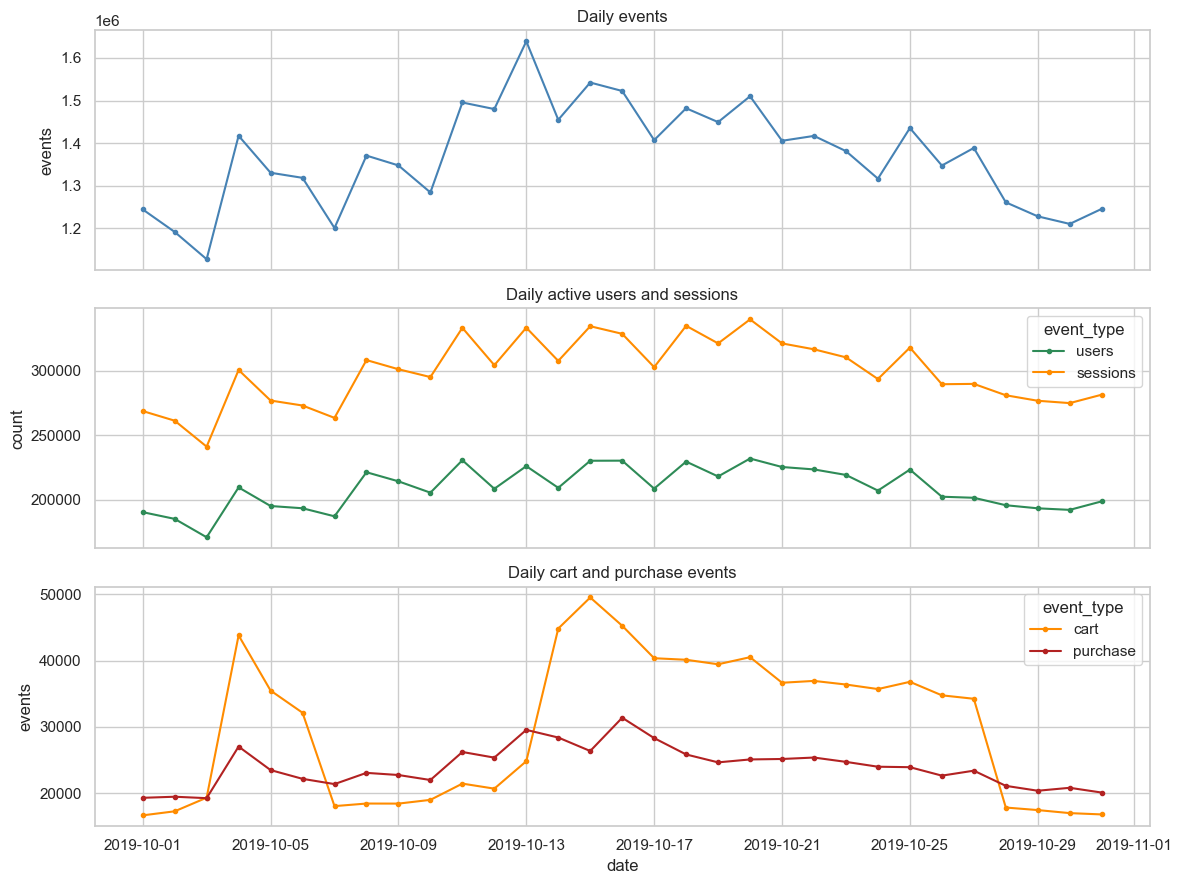

In [19]:
figure, axes = plt.subplots(3, 1, figsize=(12, 9), sharex=True)

daily["events"].plot(ax=axes[0], color="steelblue", marker="o", markersize=3,
                     title="Daily events")
axes[0].set_ylabel("events")

daily[["users", "sessions"]].plot(ax=axes[1], marker="o", markersize=3,
                                  color=["seagreen", "darkorange"],
                                  title="Daily active users and sessions")
axes[1].set_ylabel("count")

daily[["cart", "purchase"]].plot(ax=axes[2], marker="o", markersize=3,
                                 color=["darkorange", "firebrick"],
                                 title="Daily cart and purchase events")
axes[2].set_ylabel("events")
axes[2].set_xlabel("date")

plt.tight_layout()
plt.show()

## 10. Missingness and coverage

Measured across all 42.4 million rows, not sampled. Any nullability decision should rest on
these numbers.

In [20]:
missing = pd.DataFrame({
    "missing_rows": null_counts,
    "missing_percent": (null_counts / TOTAL_ROWS * 100).round(4),
    "coverage_percent": (100 - null_counts / TOTAL_ROWS * 100).round(2),
}).sort_values("missing_percent", ascending=False)

print(missing.to_string())
print()
complete = missing[missing["missing_rows"] == 0].index.tolist()
print(f"Columns with no missing values: {', '.join(complete)}")

                   missing_rows  missing_percent  coverage_percent
category_code          13515609          31.8398             68.16
brand                   6113008          14.4009             85.60
event_time                    0           0.0000            100.00
product_id                    0           0.0000            100.00
event_type                    0           0.0000            100.00
category_id                   0           0.0000            100.00
price                         0           0.0000            100.00
user_id                       0           0.0000            100.00
user_session                  2           0.0000            100.00
source_file                   0           0.0000            100.00
source_row_number             0           0.0000            100.00

Columns with no missing values: event_time, product_id, event_type, category_id, price, user_id, source_file, source_row_number


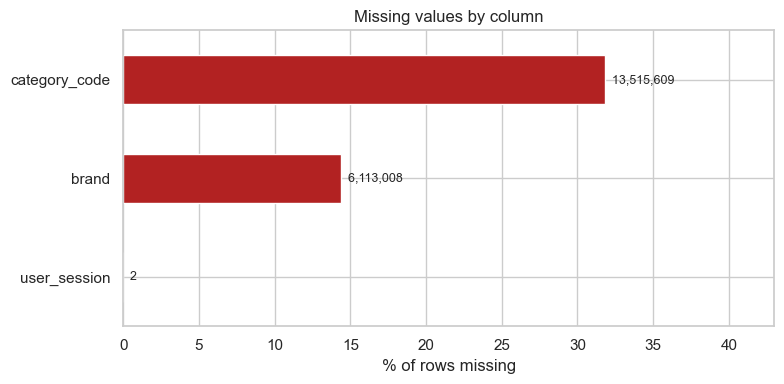

In [21]:
figure, axis = plt.subplots(figsize=(8, 4))

incomplete = missing[missing["missing_rows"] > 0].sort_values("missing_percent")
incomplete["missing_percent"].plot(kind="barh", ax=axis, color="firebrick",
                                   title="Missing values by column")
axis.set_xlabel("% of rows missing")
for position, (value, rows) in enumerate(zip(incomplete["missing_percent"],
                                             incomplete["missing_rows"])):
    axis.text(value, position, f"  {rows:,}", va="center", fontsize=9)
axis.set_xlim(right=incomplete["missing_percent"].max() * 1.35)

plt.tight_layout()
plt.show()

## 11. Price quality

Non-finite and non-positive values are counted separately from the distribution, so a bad
value cannot hide inside a percentile.

In [22]:
price_quality = pd.DataFrame([
    ("missing (null)",   int(prices.isna().sum())),
    ("not finite",       int(np.isinf(prices.to_numpy()).sum())),
    ("zero",             int((prices == 0).sum())),
    ("negative",         int((prices < 0).sum())),
    ("non-positive",     int((prices <= 0).sum())),
    ("usable (> 0)",     int((prices > 0).sum())),
], columns=["condition", "rows"])
price_quality["percent"] = (price_quality["rows"] / TOTAL_ROWS * 100).round(4)

print(price_quality.to_string(index=False))
print()

valid_prices = prices[prices > 0]
print("Distribution over positive prices:")
print(percentiles(valid_prices, "price").round(2).to_string())

     condition     rows  percent
missing (null)        0   0.0000
    not finite        0   0.0000
          zero    68673   0.1618
      negative        0   0.0000
  non-positive    68673   0.1618
  usable (> 0) 42380091  99.8382



Distribution over positive prices:


count    42380091.00
mean          290.79
p50           163.97
p90           743.62
p95          1011.58
p99          1741.34
max          2574.07


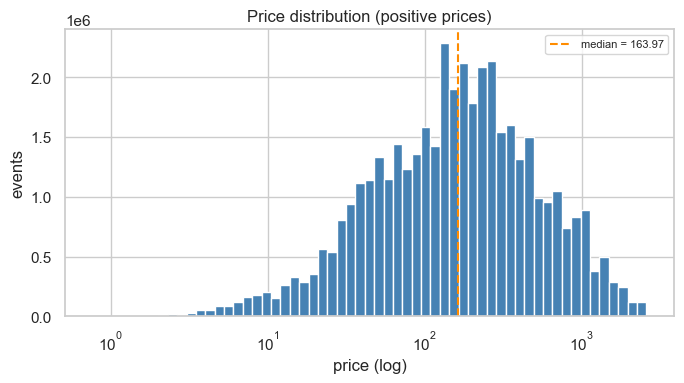

In [23]:
figure, axis = plt.subplots(figsize=(7, 4))

# Log axis because the range spans several orders of magnitude. Nothing is
# excluded from the reported numbers above; this is a display choice only.
axis.hist(valid_prices, bins=np.logspace(np.log10(valid_prices.min()),
                                         np.log10(valid_prices.max()), 60),
          color="steelblue")
axis.set_xscale("log")
axis.set_xlabel("price (log)")
axis.set_ylabel("events")
axis.set_title("Price distribution (positive prices)")
axis.axvline(valid_prices.median(), color="darkorange", linestyle="--",
             label=f"median = {valid_prices.median():.2f}")
axis.legend(fontsize=8)

plt.tight_layout()
plt.show()

## 12. Duplicates and provenance

Two different questions:

- **Provenance duplicate** — did the same raw CSV row enter the dataset twice? That would be
  an ingestion fault.
- **Repeated event** — did the same user touch the same item with the same type at the same
  instant? That can happen legitimately through a double request.

Nothing is removed here. Dropping rows changes session lengths and label counts, so that
decision belongs downstream.

In [24]:
provenance_duplicates = int(provenance.duplicated().sum())
event_duplicates = int(fingerprints.duplicated().sum())

duplicates = pd.DataFrame([
    ("duplicate source_row_number", provenance_duplicates,
     "same raw CSV row ingested twice"),
    ("repeated event", event_duplicates,
     "same user + timestamp + item + event type"),
], columns=["check", "rows", "meaning"])
duplicates["percent"] = (duplicates["rows"] / TOTAL_ROWS * 100).round(4)

print(duplicates.to_string(index=False))
print()
print(f"source_row_number range : {provenance.min():,} to {provenance.max():,}")
print(f"distinct values         : {provenance.nunique():,} of {TOTAL_ROWS:,}")
print()
print("Nothing is dropped in this task.")

                      check  rows                                   meaning  percent
duplicate source_row_number     0           same raw CSV row ingested twice   0.0000
             repeated event 35207 same user + timestamp + item + event type   0.0829

source_row_number range : 1 to 42,448,764


distinct values         : 42,448,764 of 42,448,764

Nothing is dropped in this task.


## 13. Ordering and timestamp quality

Shared timestamps are not an error, but they mean row order alone cannot define "what happened
next". That is why the canonical order carries `source_row_number` as a tie-break.

In [25]:
sessions_multi = sessions[sessions["events"] > 1]
instant_sessions = int((session_duration.loc[sessions_multi.index] == 0).sum())

ordering = pd.DataFrame([
    ("null or invalid timestamps", int(null_counts["event_time"])),
    ("order violations within the file", order_violations),
    ("multi-event sessions with zero duration", instant_sessions),
], columns=["check", "count"])

print(ordering.to_string(index=False))
print()
print(f"File ordered by event_time : {time_sorted}")
print()
print(f"{instant_sessions:,} sessions hold more than one event at the same instant.")
print("Ordering those needs the source_row_number tie-break, not the timestamp.")

                                  check  count
             null or invalid timestamps      0
       order violations within the file      0
multi-event sessions with zero duration   1575

File ordered by event_time : True

1,575 sessions hold more than one event at the same instant.
Ordering those needs the source_row_number tie-break, not the timestamp.


## 14. Extreme users and sessions

The maximum alone cannot tell a real heavy user from an ingestion artefact. The shape of the
top of the tail can. Ranks and counts only — no raw ids are printed.

In [26]:
by_user = pd.DataFrame({"events": events_per_user, "sessions": sessions_per_user})
top_users = by_user.nlargest(10, "events").reset_index(drop=True)
top_users.index = range(1, len(top_users) + 1)
top_users.index.name = "rank"

by_session = pd.DataFrame({"events": events_per_session,
                           "duration_hours": (session_duration / 3600).round(2)})
top_sessions = by_session.nlargest(10, "events").reset_index(drop=True)
top_sessions.index = range(1, len(top_sessions) + 1)
top_sessions.index.name = "rank"

print("Most active users (ids not shown):")
print(top_users.to_string())
print()
print("Largest sessions (ids not shown):")
print(top_sessions.to_string())
print()
print(f"The busiest user holds {events_per_user.max() / TOTAL_ROWS * 100:.4f}% of all events.")
print(f"The longest session ran {session_duration.max() / 3600:.1f} hours.")
print("Flagged for downstream review. Nothing is excluded in this task.")

Most active users (ids not shown):
      events  sessions
rank                  
1       7436      7400
2       4013       406
3       2912      2773
4       2894        91
5       2862       230
6       2433       142
7       2426        49
8       2390      2336
9       2316       246
10      2232        35

Largest sessions (ids not shown):
      events  duration_hours
rank                        
1       1159          153.41
2       1137            6.10
3        584            9.24
4        564            2.76
5        425            4.63
6        393          225.47
7        388            2.63
8        365            2.86
9        350            2.76
10       350            2.63

The busiest user holds 0.0175% of all events.
The longest session ran 733.5 hours.
Flagged for downstream review. Nothing is excluded in this task.


## 15. Cohort feasibility

The deliverable the next task consumes. Each row is a candidate rule and what it would leave
behind — never a chosen rule.

Read the user and event columns together. A rule can drop most users and still keep most of
the events, because activity is concentrated in a minority.

`min_active_days` counts **distinct calendar dates with activity**, not the span between the
first and last event.

> **Feasibility evidence only.** These counts are measured across the whole of October.
> Authoritative cohort membership is recomputed on the explicit training interval in
> `S1-DS-05` / `S1-DS-06` and will be smaller, because a shorter window gives every user
> fewer chances to accumulate events, sessions and active days.

In [27]:
def feasibility(min_events, min_sessions, min_active_days):
    """If this rule were applied over the full month, what would remain?

    Active days are distinct calendar dates with at least one event, not the
    span between the first and last event.
    """
    eligible = (
        (events_per_user >= min_events)
        & (sessions_per_user >= min_sessions)
        & (active_days_per_user >= min_active_days)
    )
    users = int(eligible.sum())
    events = int(events_per_user[eligible].sum())
    return {
        "min_events": min_events,
        "min_sessions": min_sessions,
        "min_active_days": min_active_days,
        "users": users,
        "user_percent": round(users / len(events_per_user) * 100, 2),
        "events": events,
        "event_percent": round(events / TOTAL_ROWS * 100, 2),
        "users_with_purchase": int((purchases_per_user[eligible] > 0).sum()),
    }


grid = pd.DataFrame([
    feasibility(5,   1, 0),
    feasibility(10,  2, 3),
    feasibility(20,  3, 7),
    feasibility(30,  3, 7),
    feasibility(50,  5, 7),
    feasibility(100, 5, 14),
])

print(grid.to_string(index=False))
print()
print("FEASIBILITY EVIDENCE ONLY - measured across the full month of October.")
print("Authoritative cohort membership is recomputed on the explicit training")
print("interval in S1-DS-05 / S1-DS-06, which will produce smaller counts.")

 min_events  min_sessions  min_active_days   users  user_percent   events  event_percent  users_with_purchase
          5             1                0 1503009         49.73 39442728          92.92               315200
         10             2                3  595672         19.71 28448158          67.02               186867
         20             3                7  132930          4.40 13338102          31.42                60622
         30             3                7  121871          4.03 13063093          30.77                58026
         50             5                7   93555          3.10 11942797          28.13                47980
        100             5               14   13140          0.43  3369047           7.94                 8077

FEASIBILITY EVIDENCE ONLY - measured across the full month of October.
Authoritative cohort membership is recomputed on the explicit training
interval in S1-DS-05 / S1-DS-06, which will produce smaller counts.


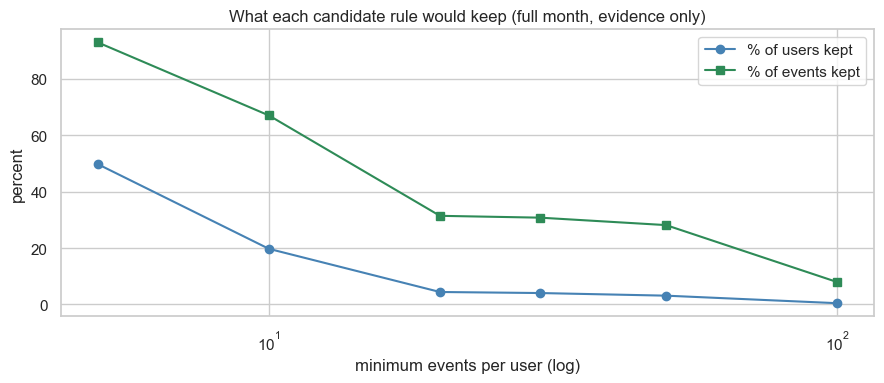

In [28]:
figure, axis = plt.subplots(figsize=(9, 4))

axis.plot(grid["min_events"], grid["user_percent"], marker="o",
          color="steelblue", label="% of users kept")
axis.plot(grid["min_events"], grid["event_percent"], marker="s",
          color="seagreen", label="% of events kept")
axis.set_xscale("log")
axis.set_xlabel("minimum events per user (log)")
axis.set_ylabel("percent")
axis.set_title("What each candidate rule would keep (full month, evidence only)")
axis.legend()

plt.tight_layout()
plt.show()

## 16. Validation

Every total is reconciled against another total computed a different way. A silent
disagreement here would invalidate everything above it.

In [29]:
validations = []


def validate(name, condition, detail=""):
    validations.append({"check": name, "status": "PASS" if condition else "FAIL",
                        "detail": detail})


validate("rows read == parquet header", rows_seen == TOTAL_ROWS,
         f"{rows_seen:,} vs {TOTAL_ROWS:,}")
validate("event-type counts sum to total", int(event_type_counts.sum()) == TOTAL_ROWS,
         f"{int(event_type_counts.sum()):,}")
validate("events per user sum to total", int(events_per_user.sum()) == TOTAL_ROWS,
         f"{int(events_per_user.sum()):,}")
validate("events per session sum to total", int(events_per_session.sum()) == TOTAL_ROWS,
         f"{int(events_per_session.sum()):,}")
validate("daily events sum to total", int(daily["events"].sum()) == TOTAL_ROWS,
         f"{int(daily['events'].sum()):,}")
validate("percentiles are ordered",
         events_per_user.quantile(0.50) <= events_per_user.quantile(0.90)
         <= events_per_user.quantile(0.95) <= events_per_user.quantile(0.99)
         <= events_per_user.max())
validate("no missing count exceeds total rows", bool((null_counts <= TOTAL_ROWS).all()))
validate("sessions per user sum to session count",
         int(sessions_per_user.sum()) == len(sessions),
         f"{int(sessions_per_user.sum()):,} vs {len(sessions):,}")
validate("usable and non-positive prices sum to total",
         int((prices > 0).sum()) + int((prices <= 0).sum()) + int(prices.isna().sum()) == TOTAL_ROWS)
validate("active days never exceed the dates covered",
         bool((active_days_per_user
               <= dates_covered.reindex(active_days_per_user.index)).all()))
validate("active days never exceed the month length",
         int(active_days_per_user.max()) <= len(daily),
         f"max {int(active_days_per_user.max())} of {len(daily)} days")
validate("provenance duplicates reported", provenance_duplicates >= 0,
         f"{provenance_duplicates:,}")

results = pd.DataFrame(validations)
print(results.to_string(index=False))
print()

failures = results[results["status"] == "FAIL"]
if len(failures):
    raise AssertionError(f"{len(failures)} validation check(s) failed")
print("All validation checks passed.")

                                      check status                   detail
                rows read == parquet header   PASS 42,448,764 vs 42,448,764
             event-type counts sum to total   PASS               42,448,764
               events per user sum to total   PASS               42,448,764
            events per session sum to total   PASS               42,448,764
                  daily events sum to total   PASS               42,448,764
                    percentiles are ordered   PASS                         
        no missing count exceeds total rows   PASS                         
     sessions per user sum to session count   PASS   9,244,772 vs 9,244,772
usable and non-positive prices sum to total   PASS                         
 active days never exceed the dates covered   PASS                         
  active days never exceed the month length   PASS        max 31 of 31 days
             provenance duplicates reported   PASS                        0

All validat

## 17. Findings and risks

Written from the numbers above. Recommendations, not rules.

In [30]:
findings = [
    f"User activity is strongly long-tailed: median {int(events_per_user.median())} events "
    f"against a mean of {events_per_user.mean():.1f}, reaching {int(events_per_user.max()):,}. "
    "Averages alone are misleading here; report percentiles.",

    f"Purchases are {event_type_counts.get('purchase', 0) / TOTAL_ROWS * 100:.2f}% of events, "
    f"{users_with_purchase / total_users * 100:.1f}% of users and "
    f"{sessions_with_purchase / total_sessions * 100:.1f}% of sessions. "
    "T2 will be heavily imbalanced; rank-aware metrics such as PR-AUC fit, accuracy does not.",

    f"{single_event_users:,} users ({single_event_users / len(events_per_user) * 100:.1f}%) have "
    f"exactly one event and {single_session_users:,} "
    f"({single_session_users / len(events_per_user) * 100:.1f}%) have exactly one session. "
    "Neither group carries a sequence to learn from.",

    f"{single_event_sessions / len(sessions) * 100:.1f}% of sessions hold exactly one event, "
    "so a large share of sessions carry no within-session sequence.",

    f"category_code is missing on {null_counts['category_code'] / TOTAL_ROWS * 100:.2f}% of "
    f"rows while category_id is complete. Modelling can use the {len(categories)} ids, but a "
    "demo cannot show a readable name for every event.",

    "The event vocabulary is view, cart and purchase only. There is no remove-from-cart event, "
    "so no downstream rule may assume one exists.",

    f"Null sessions are extremely rare ({int(null_counts['user_session'])} rows) but not zero, "
    "so session handling still needs a defined path for them.",

    f"{instant_sessions:,} multi-event sessions occur at a single instant, and "
    f"{event_duplicates:,} events repeat exactly. Ordering must use the source_row_number "
    "tie-break rather than the timestamp alone.",

    f"Median user is active on {int(active_days_per_user.median())} distinct day(s) while the "
    f"median calendar span is {span_days.median():.2f} days. Span overstates engagement and "
    "should not be used as an eligibility signal on its own.",

    f"The most active user holds {int(events_per_user.max()):,} events and the largest session "
    f"holds {int(events_per_session.max()):,}. These need a downstream policy review before "
    "training, but nothing is excluded in this task.",
]

for number, finding in enumerate(findings, start=1):
    print(f"{number}. {finding}")
    print()

1. User activity is strongly long-tailed: median 4 events against a mean of 14.0, reaching 7,436. Averages alone are misleading here; report percentiles.

2. Purchases are 1.75% of events, 11.5% of users and 6.8% of sessions. T2 will be heavily imbalanced; rank-aware metrics such as PR-AUC fit, accuracy does not.

3. 691,246 users (22.9%) have exactly one event and 1,475,463 (48.8%) have exactly one session. Neither group carries a sequence to learn from.

4. 35.4% of sessions hold exactly one event, so a large share of sessions carry no within-session sequence.

5. category_code is missing on 31.84% of rows while category_id is complete. Modelling can use the 624 ids, but a demo cannot show a readable name for every event.

6. The event vocabulary is view, cart and purchase only. There is no remove-from-cart event, so no downstream rule may assume one exists.

7. Null sessions are extremely rare (2 rows) but not zero, so session handling still needs a defined path for them.

8. 1,575 

## 18. Machine-readable artifact

Every official number in one JSON file, organised by section, so the next task reads them
instead of copying by hand. The tables and charts above are generated from these same values.

In [31]:
def as_floats(series):
    return {str(key): float(value) for key, value in series.items()}


audit = {
    "source": SOURCE_PARQUET.name,
    "rows_audited": int(rows_seen),
    "reconciliation": reconciliation.to_dict(orient="records"),
    "dataset_totals": {row["measure"]: int(row["count"]) for _, row in volume.iterrows()},
    "event_types": {str(k): int(v) for k, v in event_type_counts.items()},
    "sparsity": {row["measure"]: {"count": int(row["count"]), "percent": float(row["percent"])}
                 for _, row in sparsity.iterrows()},
    "user_activity": {
        "percentiles": as_floats(percentiles(events_per_user, "events per user")),
        "reach": user_reach.to_dict(orient="records"),
        "sessions_per_user": as_floats(percentiles(sessions_per_user, "sessions per user")),
        "sessions_reach": session_reach.to_dict(orient="records"),
        "single_event_users": single_event_users,
        "single_session_users": single_session_users,
        "active_days": as_floats(percentiles(active_days_per_user, "active days")),
        "active_days_reach": day_reach.to_dict(orient="records"),
        "active_span_days": as_floats(percentiles(span_days, "calendar span days")),
        "active_days_note": ("active_days counts distinct calendar dates with at least one "
                             "event; active_span_days is last_seen - first_seen and is "
                             "descriptive only"),
    },
    "session_activity": {
        "events_per_session": as_floats(percentiles(events_per_session, "events per session")),
        "single_event_sessions": single_event_sessions,
    },
    "session_duration": {
        "seconds": as_floats(percentiles(session_duration, "duration")),
        "buckets": duration_buckets.to_dict(orient="records"),
    },
    "time_coverage": {
        "first_timestamp": str(first_seen.min()),
        "last_timestamp": str(last_seen.max()),
        "days_present": int(len(daily)),
        "missing_days": [str(day) for day in missing_days],
        "daily": {str(day): {column: int(value) for column, value in row.items()}
                  for day, row in daily.iterrows()},
    },
    "missingness": {str(column): {"rows": int(row["missing_rows"]),
                                  "percent": float(row["missing_percent"])}
                    for column, row in missing.iterrows()},
    "price_quality": {
        "conditions": price_quality.to_dict(orient="records"),
        "percentiles": as_floats(percentiles(valid_prices, "price")),
    },
    "duplicates": duplicates.drop(columns="meaning").to_dict(orient="records"),
    "ordering": ordering.to_dict(orient="records"),
    "extremes": {
        "max_events_per_user": int(events_per_user.max()),
        "max_sessions_per_user": int(sessions_per_user.max()),
        "max_events_per_session": int(events_per_session.max()),
        "max_session_duration_seconds": float(session_duration.max()),
    },
    "cohort_feasibility": {
        "basis": "full October window, active_days = distinct dates with activity",
        "status": "feasibility evidence only - not an authoritative cohort",
        "recomputed_in": "S1-DS-05 / S1-DS-06 on the explicit training interval",
        "grid": grid.to_dict(orient="records"),
    },
    "validation": results.to_dict(orient="records"),
    "findings": findings,
}

audit_path = OUTPUT_DIR / "data_audit_pass1.json"
audit_path.write_text(json.dumps(audit, indent=2), encoding="utf-8")

print(f"{audit_path.name}  {audit_path.stat().st_size / 1024:.1f} KB")
print(f"sections: {', '.join(audit.keys())}")
print()
print(f"Rows audited : {rows_seen:,}")
print("Every number covers the full dataset, not a sample.")

data_audit_pass1.json  19.4 KB
sections: source, rows_audited, reconciliation, dataset_totals, event_types, sparsity, user_activity, session_activity, session_duration, time_coverage, missingness, price_quality, duplicates, ordering, extremes, cohort_feasibility, validation, findings

Rows audited : 42,448,764
Every number covers the full dataset, not a sample.


## What this hands over

| Section | Used by |
|---|---|
| `cohort_feasibility`, `user_activity` | the cohort rule — how many users each candidate keeps, over the full month |
| `sparsity`, `event_types` | the T3 protocol — whether cart and purchase signal is dense enough |
| `session_activity`, `session_duration` | the sessionisation policy |
| `missingness`, `price_quality` | feature design, and what a demo can display |
| `duplicates`, `ordering` | the deduplication and tie-break policy |

## Deliberately not decided here

The minimum event count, the minimum session count, the active-day threshold, the session
timeout, any outlier or filtering policy, and any price transformation. This task supplies the
evidence; the choices are made against it, in the open, downstream.